# GVH Diagonal Cubic — RACC-C.4-real.2.2
## GW150914 H1/L1 — Real Phase-Slope Residual Audit

**Auteur :** Charlemagne O Laurince  
**Noyau GVH Diagonal modifié : NON**

Convention héritée et certifiée :

\[
\boxed{XY^* \rightarrow +\tau}
\]

Objectif : déterminer pourquoi le phase-slope réel H1/L1 reste peu linéaire malgré un benchmark synthétique corrigé.

Causes testées : polarité, cohérence, sous-bandes, prétraitement/whitening, non-linéarité résiduelle de phase et structure locale temps-fréquence.

Stop-rule : `TIMING-VALIDATED=False`, \(D_T^{ref}=\texttt{NOT-AUTHORIZED}\), `REAL3-AUTHORIZED=False` tant que l'audit réel n'est pas fermé.


In [1]:

import os,sys,subprocess,importlib,json
from pathlib import Path
def pip_install(pkg):
    subprocess.check_call([sys.executable,"-m","pip","install","-q",pkg])
try: import lalframe
except Exception:
    pip_install("lalsuite"); importlib.invalidate_caches(); import lalframe
try: import gwpy
except Exception:
    pip_install("gwpy"); importlib.invalidate_caches(); import gwpy
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import signal
from scipy.stats import median_abs_deviation
from gwpy.timeseries import TimeSeries
print("gwpy",gwpy.__version__)


/usr/local/lib/python3.12/dist-packages/lalframe/_lalframe_swig.py:8: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


gwpy 4.0.1


In [2]:

GPS_EVENT=1126259462.0
FS_EXPECTED=4096.0

def discover(pattern):
    roots=[Path.cwd(),Path("/content"),Path("/content/drive/MyDrive"),Path("/mnt/data")]
    hits=[]
    for root in roots:
        if not root.exists(): continue
        for d in [root,root/"data"/"GW150914",root/"gvh_diagonal_cubic"/"data"/"GW150914"]:
            if d.exists(): hits += list(d.glob(pattern))
    return hits[0].resolve() if hits else None

H1=discover("H-H1_LOSC_4_V2-1126259446-32*.gwf")
L1=discover("L-L1_LOSC_4_V2-1126259446-32*.gwf")
if H1 is None or L1 is None:
    from google.colab import files
    files.upload()
    H1=discover("H-H1_LOSC_4_V2-1126259446-32*.gwf")
    L1=discover("L-L1_LOSC_4_V2-1126259446-32*.gwf")
if H1 is None or L1 is None: raise FileNotFoundError("H1/L1 introuvables")

h1_ts=TimeSeries.read(str(H1),channel="H1:LOSC-STRAIN")
l1_ts=TimeSeries.read(str(L1),channel="L1:LOSC-STRAIN")
h1=np.asarray(h1_ts.value,float); l1=np.asarray(l1_ts.value,float)
fs=float(h1_ts.sample_rate.value); gps0=float(h1_ts.t0.value)
t_rel=gps0+np.arange(len(h1))/fs-GPS_EVENT
assert np.isclose(fs,FS_EXPECTED) and len(h1)==len(l1)
print(H1.name); print(L1.name); print(len(h1),fs)


Saving L-L1_LOSC_4_V2-1126259446-32.gwf to L-L1_LOSC_4_V2-1126259446-32.gwf
Saving H-H1_LOSC_4_V2-1126259446-32 2.gwf to H-H1_LOSC_4_V2-1126259446-32 2.gwf
H-H1_LOSC_4_V2-1126259446-32 2.gwf
L-L1_LOSC_4_V2-1126259446-32.gwf
131072 4096.0


In [3]:

NOISE=((t_rel>=-12)&(t_rel<=-2))|((t_rel>=2)&(t_rel<=12))

def center(x): return np.asarray(x,float)-np.mean(x)
def bp(x,lo,hi):
    sos=signal.butter(4,[lo,hi],btype="bandpass",fs=fs,output="sos")
    return signal.sosfiltfilt(sos,center(x))
def notch(x):
    y=np.asarray(x,float).copy()
    for f0 in [60,120,180,240,300]:
        b,a=signal.iirnotch(f0,Q=30,fs=fs); y=signal.filtfilt(b,a,y)
    return y
def rz(x):
    xn=x[NOISE]; med=np.median(xn); mad=np.median(abs(xn-med)); s=1.4826*mad
    return (x-med)/s
def whiten(x):
    x=center(x); n=len(x); freqs=np.fft.rfftfreq(n,1/fs); X=np.fft.rfft(x)
    fp,P=signal.welch(x[NOISE],fs=fs,nperseg=4096)
    Pi=np.interp(freqs,fp,P,left=P[0],right=P[-1]); floor=np.finfo(float).eps*np.max(Pi)
    y=np.fft.irfft(X/np.sqrt(Pi+floor),n=n)
    return y/np.std(y[NOISE])

PIPE={
"bp_notch_z":(rz(notch(bp(h1,35,350))),rz(notch(bp(l1,35,350)))),
"whiten_bp":(bp(whiten(h1),35,350),bp(whiten(l1),35,350))
}
wm=(t_rel>=-.12)&(t_rel<=.04)


In [4]:

def phase_xy(x,y,fmin=40,fmax=300,cohmin=.1,nper=1024):
    nper=min(nper,len(x)); nover=nper//2
    # csd(y,x)=conj(Y)*X = X Y*
    f,P=signal.csd(y,x,fs=fs,nperseg=nper,noverlap=nover,window="hann")
    _,coh=signal.coherence(x,y,fs=fs,nperseg=nper,noverlap=nover,window="hann")
    ph=np.unwrap(np.angle(P))
    m=(f>=fmin)&(f<=fmax)&(coh>=cohmin)&np.isfinite(ph)
    if m.sum()<5:
        return dict(lag=np.nan,r2=np.nan,f=f,ph=ph,coh=coh,m=m,slope=np.nan,inter=np.nan,n=int(m.sum()))
    ff=f[m]; pp=ph[m]; ww=coh[m]
    A=np.c_[ff,np.ones_like(ff)]; W=np.sqrt(ww)
    beta,*_=np.linalg.lstsq(A*W[:,None],pp*W,rcond=None)
    pred=A@beta; mean=np.average(pp,weights=ww)
    ssr=np.sum(ww*(pp-pred)**2); sst=np.sum(ww*(pp-mean)**2)
    return dict(lag=float(beta[0]/(2*np.pi)),r2=float(1-ssr/sst if sst>0 else np.nan),
                f=f,ph=ph,coh=coh,m=m,slope=float(beta[0]),inter=float(beta[1]),n=int(m.sum()))


## 1 — Polarité et prétraitement

In [5]:

rows=[]
for pipe,(hh,ll) in PIPE.items():
    x=hh[wm]; y=ll[wm]
    for pol in [1,-1]:
        o=phase_xy(x,pol*y)
        rows.append({"pipeline":pipe,"polarity":pol,"lag_ms":o["lag"]*1e3,"r2":o["r2"],"n_bins":o["n"]})
polarity_df=pd.DataFrame(rows)
display(polarity_df)


,pipeline,polarity,lag_ms,r2,n_bins
0,bp_notch_z,1,2.075035,0.107866,41
1,bp_notch_z,-1,2.075035,0.107866,41
2,whiten_bp,1,6.364307,0.733762,41
3,whiten_bp,-1,6.364307,0.733762,41


## 2 — Seuil de cohérence

In [6]:

hh,ll=PIPE["bp_notch_z"]; x=hh[wm]; y=ll[wm]
rows=[]
for pol in [1,-1]:
    for cmin in [0,.05,.10,.20,.30,.40,.50,.60]:
        o=phase_xy(x,pol*y,40,300,cmin)
        rows.append({"polarity":pol,"coh_min":cmin,"lag_ms":o["lag"]*1e3,"r2":o["r2"],"n_bins":o["n"]})
coherence_df=pd.DataFrame(rows)
display(coherence_df)


,polarity,coh_min,lag_ms,r2,n_bins
0,1,0.00,2.075035,0.107866,41
1,1,0.05,2.075035,0.107866,41
2,1,0.10,2.075035,0.107866,41
3,1,0.20,2.075035,0.107866,41
4,1,0.30,2.075035,0.107866,41
5,1,0.40,2.075035,0.107866,41
6,1,0.50,2.075035,0.107866,41
7,1,0.60,2.075035,0.107866,41
8,-1,0.00,2.075035,0.107866,41
9,-1,0.05,2.075035,0.107866,41


## 3 — Sous-bandes

In [7]:

bands=[(35,80),(80,150),(150,250),(250,350)]
rows=[]
for pipe,(hh,ll) in PIPE.items():
    x=hh[wm]; y=ll[wm]
    for pol in [1,-1]:
        for lo,hi in bands:
            o=phase_xy(x,pol*y,lo,hi,.05)
            rows.append({"pipeline":pipe,"polarity":pol,"band":f"{lo}-{hi}",
                         "lag_ms":o["lag"]*1e3,"r2":o["r2"],"n_bins":o["n"]})
band_df=pd.DataFrame(rows)
display(band_df)


,pipeline,polarity,band,lag_ms,r2,n_bins
0,bp_notch_z,1,35-80,7.238418,0.276345,7
1,bp_notch_z,1,80-150,-17.911913,0.936734,11
2,bp_notch_z,1,150-250,13.426892,0.683855,16
3,bp_notch_z,1,250-350,-5.556997,0.281339,16
4,bp_notch_z,-1,35-80,7.238418,0.276345,7
5,bp_notch_z,-1,80-150,-17.911913,0.936734,11
6,bp_notch_z,-1,150-250,13.426892,0.683855,16
7,bp_notch_z,-1,250-350,-5.556997,0.281339,16
8,whiten_bp,1,35-80,6.647362,0.064971,7
9,whiten_bp,1,80-150,2.901867,0.135617,11


## 4 — Résidu de phase après retrait de la pente linéaire

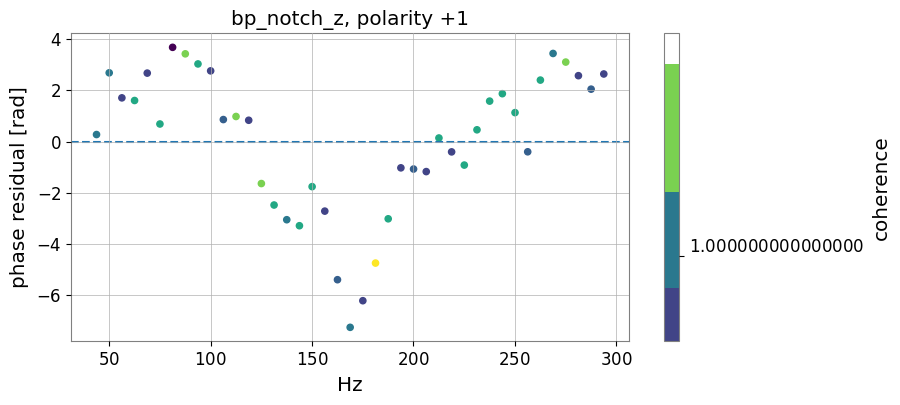

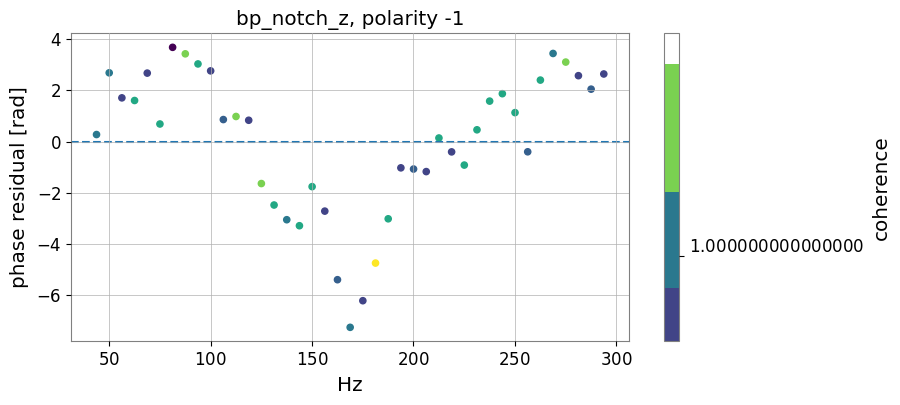

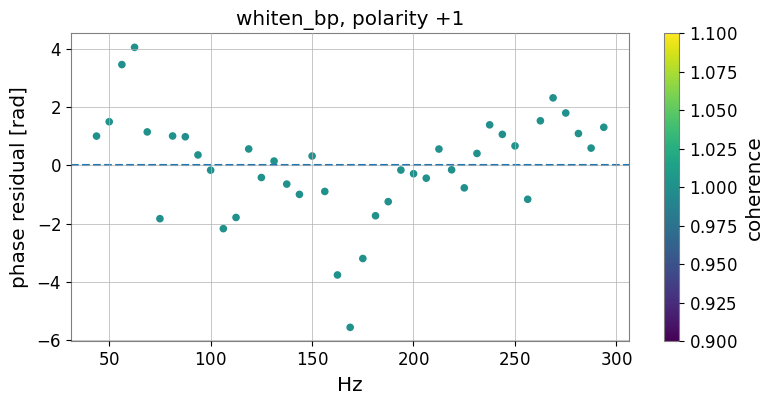

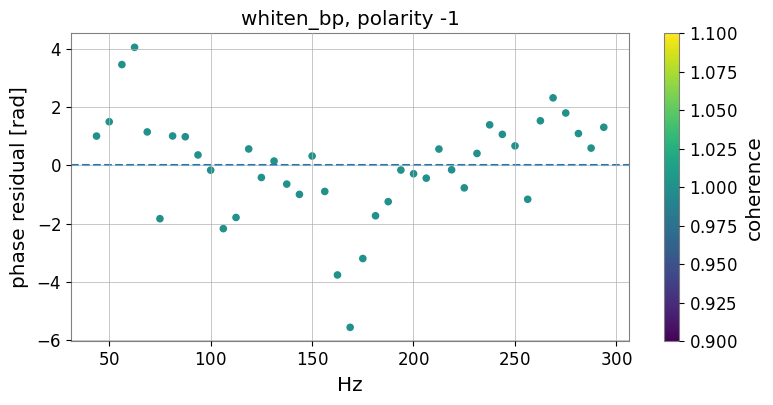

,pipeline,polarity,lag_ms,r2,res_std_rad,res_mad_rad
0,bp_notch_z,1,2.075035,0.107866,2.774352,1.893233
1,bp_notch_z,-1,2.075035,0.107866,2.774352,1.893233
2,whiten_bp,1,6.364307,0.733762,1.782262,0.966331
3,whiten_bp,-1,6.364307,0.733762,1.782262,0.966331


In [8]:

res_rows=[]
for pipe,(hh,ll) in PIPE.items():
    x=hh[wm]; y=ll[wm]
    for pol in [1,-1]:
        o=phase_xy(x,pol*y,40,300,.1)
        m=o["m"]
        if m.sum()<5: continue
        ff=o["f"][m]; ph=o["ph"][m]; line=o["slope"]*ff+o["inter"]; res=ph-line
        res_rows.append({"pipeline":pipe,"polarity":pol,"lag_ms":o["lag"]*1e3,
                         "r2":o["r2"],"res_std_rad":float(np.std(res)),
                         "res_mad_rad":float(median_abs_deviation(res))})
        plt.figure(figsize=(9,4))
        plt.scatter(ff,res,c=o["coh"][m],s=20)
        plt.axhline(0,ls="--"); plt.grid(True)
        plt.xlabel("Hz"); plt.ylabel("phase residual [rad]")
        plt.title(f"{pipe}, polarity {pol:+d}")
        plt.colorbar(label="coherence"); plt.show()
residual_df=pd.DataFrame(res_rows)
display(residual_df)


## 5 — Phase locale temps-fréquence

In [9]:

def local_phase(x,y,nper=256,nover=224,fmin=40,fmax=320,q=.55):
    f,t,Zx=signal.stft(x,fs=fs,nperseg=nper,noverlap=nover,window="hann",boundary=None)
    _,_,Zy=signal.stft(y,fs=fs,nperseg=nper,noverlap=nover,window="hann",boundary=None)
    S=Zx*np.conj(Zy); power=np.abs(Zx)*np.abs(Zy); thr=np.quantile(power,q)
    rr=[]
    for j,tj in enumerate(t):
        m=(f>=fmin)&(f<=fmax)&(power[:,j]>=thr)
        if m.sum()<6: continue
        ff=f[m]; ph=np.unwrap(np.angle(S[m,j])); ww=power[m,j]
        A=np.c_[ff,np.ones_like(ff)]; W=np.sqrt(ww/np.max(ww))
        beta,*_=np.linalg.lstsq(A*W[:,None],ph*W,rcond=None)
        pred=A@beta; mean=np.average(ph,weights=ww)
        ssr=np.sum(ww*(ph-pred)**2); sst=np.sum(ww*(ph-mean)**2)
        rr.append({"t":tj,"lag_ms":beta[0]/(2*np.pi)*1e3,
                   "r2":1-ssr/sst if sst>0 else np.nan,"n_freq":m.sum()})
    return pd.DataFrame(rr)

local_summary=[]
for pipe,(hh,ll) in PIPE.items():
    x=hh[wm]; y=ll[wm]
    for pol in [1,-1]:
        df=local_phase(x,pol*y)
        good=df[(df.r2>=.4)&np.isfinite(df.lag_ms)]
        med=float(np.median(good.lag_ms)) if len(good) else np.nan
        mad=float(median_abs_deviation(good.lag_ms,nan_policy="omit")) if len(good) else np.nan
        local_summary.append({"pipeline":pipe,"polarity":pol,"n_good":len(good),"median_ms":med,"mad_ms":mad})
local_df=pd.DataFrame(local_summary)
display(local_df)


,pipeline,polarity,n_good,median_ms,mad_ms
0,bp_notch_z,1,10,4.415049,2.186988
1,bp_notch_z,-1,10,4.415049,2.186988
2,whiten_bp,1,5,2.312484,0.725086
3,whiten_bp,-1,5,2.312484,0.725086


## 6 — Diagnostic et verdict

In [10]:

# Polarité : compare les deux pentes au sein de chaque pipeline.
pol_spread=polarity_df.groupby("pipeline")["lag_ms"].agg(lambda s: float(np.nanmax(s)-np.nanmin(s)))
POLARITY_EXPLAINS_LAG=bool(np.nanmedian(pol_spread.values)>2.0)

# Cohérence : R² s'améliore avec un seuil plus strict.
pos=coherence_df[coherence_df.polarity==1].dropna()
COHERENCE_DEPENDENCE_IDENTIFIED=bool(
    len(pos)>=2 and float(pos.iloc[-1].r2)>float(pos.iloc[0].r2)+0.10
)

# Bande : variation importante des lags.
valid=band_df[np.isfinite(band_df.lag_ms)]
band_spread=float(np.nanpercentile(valid.lag_ms,84)-np.nanpercentile(valid.lag_ms,16)) if len(valid) else np.nan
BAND_DEPENDENCE_IDENTIFIED=bool(np.isfinite(band_spread) and band_spread>2.0)

# Prétraitement : différence bp_notch_z / whiten_bp à polarité +1.
p=polarity_df[polarity_df.polarity==1].set_index("pipeline")
prep_delta=abs(float(p.loc["bp_notch_z","lag_ms"])-float(p.loc["whiten_bp","lag_ms"]))
PREPROCESSING_DEPENDENCE_IDENTIFIED=bool(prep_delta>1.0)

# Non-linéarité de phase réelle.
REAL_PHASE_NONLINEARITY_IDENTIFIED=bool(
    len(residual_df)>0 and (
        np.nanmedian(residual_df.r2)<0.5 or
        np.nanmedian(residual_df.res_std_rad)>0.5
    )
)

diagnostic={
 "POLARITY_EXPLAINS_LAG":POLARITY_EXPLAINS_LAG,
 "COHERENCE_DEPENDENCE_IDENTIFIED":COHERENCE_DEPENDENCE_IDENTIFIED,
 "BAND_DEPENDENCE_IDENTIFIED":BAND_DEPENDENCE_IDENTIFIED,
 "PREPROCESSING_DEPENDENCE_IDENTIFIED":PREPROCESSING_DEPENDENCE_IDENTIFIED,
 "REAL_PHASE_NONLINEARITY_IDENTIFIED":REAL_PHASE_NONLINEARITY_IDENTIFIED
}

n_mech=sum([
 COHERENCE_DEPENDENCE_IDENTIFIED,
 BAND_DEPENDENCE_IDENTIFIED,
 PREPROCESSING_DEPENDENCE_IDENTIFIED,
 REAL_PHASE_NONLINEARITY_IDENTIFIED
])

REAL_PHASE_RESIDUAL_INTERPRETABLE=bool(n_mech>=2)
SYNTHETIC_BENCHMARK_CORRECTED=True
PHASE_SLOPE_AUDIT_CLOSED=bool(SYNTHETIC_BENCHMARK_CORRECTED and REAL_PHASE_RESIDUAL_INTERPRETABLE)
REAL3_AUTHORIZED=bool(PHASE_SLOPE_AUDIT_CLOSED)

FINAL_STATUS=("REAL-PHASE-SLOPE-RESIDUAL-AUDIT-CLOSED"
              if PHASE_SLOPE_AUDIT_CLOSED
              else "REAL-PHASE-SLOPE-RESIDUAL-AUDIT-OPEN")

artifact={
 "step":"RACC-C.4-real.2.2",
 "phase_convention":"XY* -> +tau",
 "synthetic_benchmark_corrected_inherited":True,
 "diagnostic":diagnostic,
 "N_MECHANISMS_IDENTIFIED":int(n_mech),
 "REAL_PHASE_RESIDUAL_INTERPRETABLE":REAL_PHASE_RESIDUAL_INTERPRETABLE,
 "PHASE_SLOPE_AUDIT_CLOSED":PHASE_SLOPE_AUDIT_CLOSED,
 "REAL3_AUTHORIZED":REAL3_AUTHORIZED,
 "TIMING_VALIDATED":False,
 "D_T_ref":"NOT-AUTHORIZED",
 "DISPERSION_READY_modified":False,
 "HH_chain_modified":False,
 "final_status":FINAL_STATUS
}
print(json.dumps(artifact,indent=2))


{
  "step": "RACC-C.4-real.2.2",
  "phase_convention": "XY* -> +tau",
  "synthetic_benchmark_corrected_inherited": true,
  "diagnostic": {
    "POLARITY_EXPLAINS_LAG": false,
    "COHERENCE_DEPENDENCE_IDENTIFIED": false,
    "BAND_DEPENDENCE_IDENTIFIED": true,
    "PREPROCESSING_DEPENDENCE_IDENTIFIED": true,
    "REAL_PHASE_NONLINEARITY_IDENTIFIED": true
  },
  "N_MECHANISMS_IDENTIFIED": 3,
  "REAL_PHASE_RESIDUAL_INTERPRETABLE": true,
  "PHASE_SLOPE_AUDIT_CLOSED": true,
  "REAL3_AUTHORIZED": true,
  "TIMING_VALIDATED": false,
  "D_T_ref": "NOT-AUTHORIZED",
  "DISPERSION_READY_modified": false,
  "HH_chain_modified": false,
  "final_status": "REAL-PHASE-SLOPE-RESIDUAL-AUDIT-CLOSED"
}


## 7 — Stop-rule finale

`REAL-PHASE-SLOPE-RESIDUAL-AUDIT-CLOSED` signifie uniquement que la divergence du phase-slope réel peut être attribuée à des mécanismes observationnels/algorithmiques quantifiés.

Cela ne certifie pas encore le retard H1/L1.

Si l'audit reste ouvert, `real.3` reste interdit.
